# Motion and path generation

This notebook introduces the motion-generation workflow in RobotBlockSet. It shows how to generate point-to-point trajectories and how to construct more complex paths in joint space and task space.


## What this notebook covers

The examples demonstrate the main trajectory-generation tools, interpolation methods, and path-construction utilities provided by RobotBlockSet. They cover smooth joint trajectories, Cartesian trajectories, and geometric paths built from multiple points or orientation changes.

Use this notebook as a practical reference when you want to create motion profiles, compare trajectory types, or prepare paths that will later be tracked by a controller or used in simulation.


# Imports


In [96]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

from robotblockset.transformations import *
from robotblockset.tools import gradientPath, gradientCartesianPath, gradientQuaternionPath
from robotblockset.trajectories import jjerk, jpoly, jtrap, jline, cpoly, cjerk, ctrap, cline, ctraj, carctraj, interpPath, interpQuaternionPath, interpCartesianPath, pathoverpoints, pathlen, distance2path, qspline
from robotblockset.graphics import plotcpos_ori, plotucs, plotpathpoints, plotjtraj, plotctraj, plotcpath, plotspheregrid
from robotblockset.rbf import encodeRBF, decodeCartesianRBF

np.set_printoptions(precision=4, suppress=True)

# Trajectory generation

One important function of a robotics toolbox is generating paths and trajectories. RobotBlockSet provides tools for joint-space and task-space trajectory generation.

Trajectory generation is based on interpolation, but it also includes timing. A trajectory specifies how the robot moves from an initial position to a final position over time, including the velocity and acceleration profiles.

## Joint-space trajectories

RobotBlockSet provides several functions for joint-space trajectory generation:

| Function | Description |
| --- | --- |
| `[qt, qdt, qddt] = jjerk(q0, q1, t, ...)` | Jerk-limited trajectory based on Ruckig. |
| `[qt, qdt, qddt] = jpoly(q0, q1, t, ...)` | Fifth-order polynomial trajectory. Optional initial and final velocities can be provided. |
| `[qt, qdt, qddt] = jtrap(q0, q1, t, ta)` | Trajectory with trapezoidal velocity profile. |
| `[qt, qdt, qddt] = jline(q0, q1, t)` | Trajectory with constant velocity. |

These functions generate interpolated joint positions, velocities, and accelerations for motion from initial configuration `q0` to final configuration `q1` at the time samples in `t`.


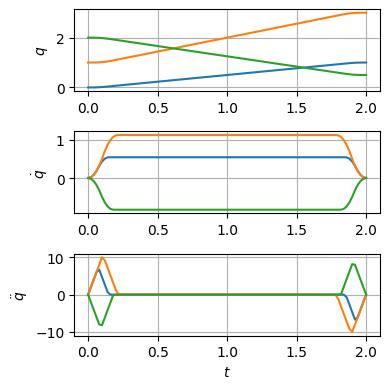

In [2]:
t = np.arange(0, 2.0001, 0.02)
qt, qdt, qddt = jjerk([0, 1, 2], [1, 3, 0.5], t)
_ = plotjtraj(t, qt, qdt, qddt, fig_size=(4, 4))

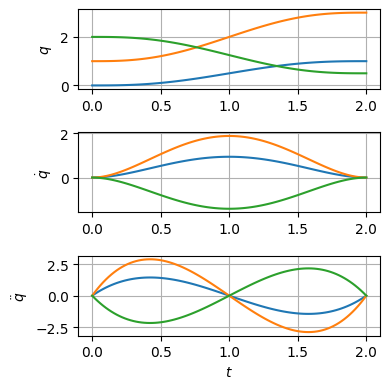

In [3]:
t = np.arange(0, 2.0001, 0.02)
qt, qdt, qddt = jpoly([0, 1, 2], [1, 3, 0.5], t)
_ = plotjtraj(t, qt, qdt, qddt, fig_size=(4, 4))

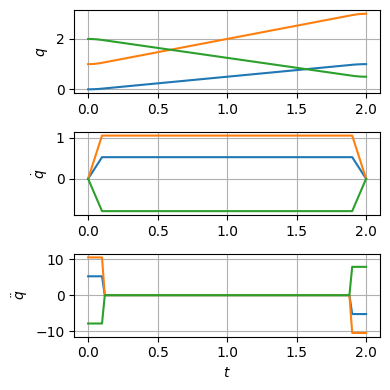

In [4]:
t = np.arange(0, 2.0001, 0.02)
qt, qdt, qddt = jtrap([0, 1, 2], [1, 3, 0.5], t)
_ = plotjtraj(t, qt, qdt, qddt, fig_size=(4, 4))

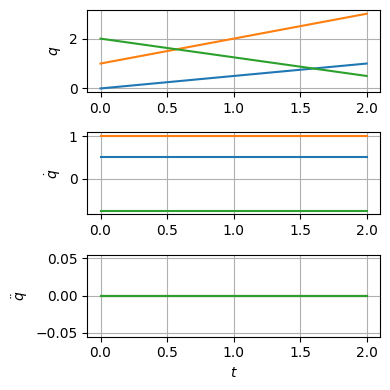

In [5]:
t = np.arange(0, 2.0001, 0.02)
qt, qdt, qddt = jline([0, 1, 2], [1, 3, 0.5], t)
_ = plotjtraj(t, qt, qdt, qddt, fig_size=(4, 4))

## Task-space trajectories

RobotBlockSet also provides trajectory generators for Cartesian motion:

| Function | Description |
| --- | --- |
| `[xt, vt, at] = cpoly(x0, x1, t)` | Cartesian trajectory based on a fifth-order polynomial profile. |
| `[xt, vt, at] = cjerk(x0, x1, t, ...)` | Cartesian trajectory based on a jerk-limited profile. |
| `[xt, vt, at] = ctrap(x0, x1, t, ta)` | Cartesian trajectory with a trapezoidal velocity profile. |
| `[xt, vt, at] = cline(x0, x1, t)` | Cartesian trajectory with constant velocity. |
| `[xt, vt, at] = ctraj(x0, x1, t, fun)` | Cartesian trajectory with a custom scalar motion profile. |
| `[xt, vt, at] = carctraj(x0, x1, pC, t, fun)` | Cartesian trajectory along an arc with a custom scalar motion profile. |

These functions generate interpolated poses, velocities, and accelerations for motion from initial pose `x0` to final pose `x1` at the time samples in `t`. Positions are interpolated linearly and orientations are interpolated with spherical linear interpolation (SLERP).


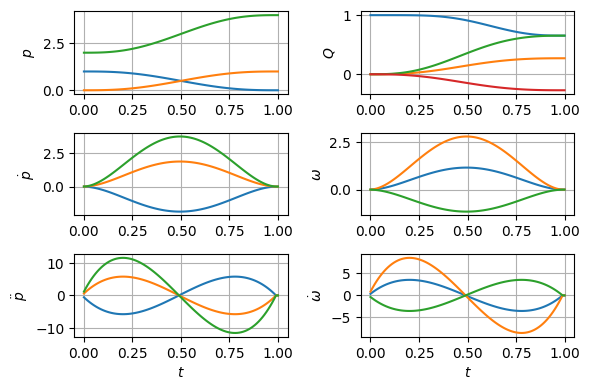

In [6]:
T0 = rp2t(np.eye(3), [1, 0, 2], out="T")
T1 = rp2t(rot_y(np.pi / 2, out="R") @ rot_x(np.pi / 4, out="R"), [0, 1, 4], out="T")
t = np.arange(0, 1.0001, 0.01)
xt, vt, at = cpoly(t2x(T0), t2x(T1), t)
_ = plotctraj(t, xt, vt, at, fig_size=(6, 4))

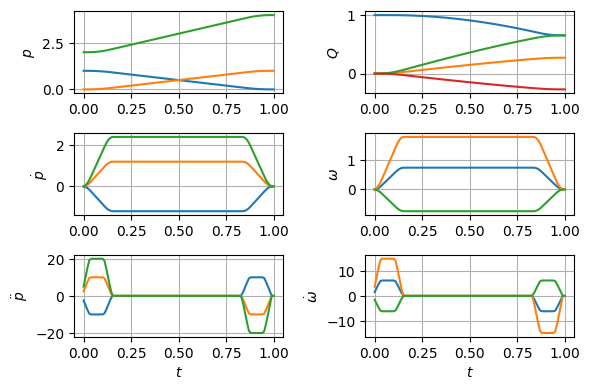

In [7]:
T0 = rp2t(np.eye(3), [1, 0, 2], out="T")
T1 = rp2t(rot_y(np.pi / 2, out="R") @ rot_x(np.pi / 4, out="R"), [0, 1, 4], out="T")
t = np.arange(0, 1.01, 0.01)
xt, vt, at = cjerk(t2x(T0), t2x(T1), t, v_max=5, a_max=20, jerk_max=500)
t = np.arange(xt.shape[0]) * 0.01
_ = plotctraj(t, xt, vt, at, fig_size=(6, 4))

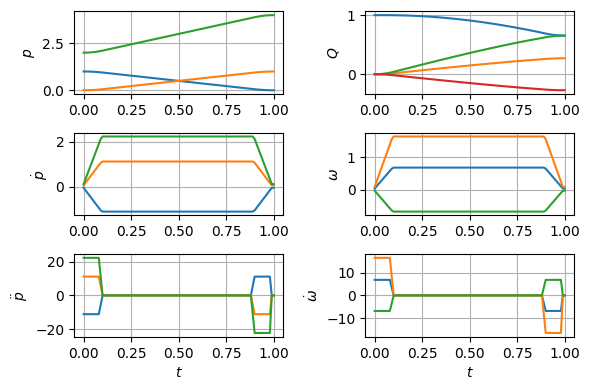

In [8]:
xt, vt, at = ctrap(t2x(T0), t2x(T1), t)
_ = plotctraj(t, xt, vt, at, fig_size=(6, 4))

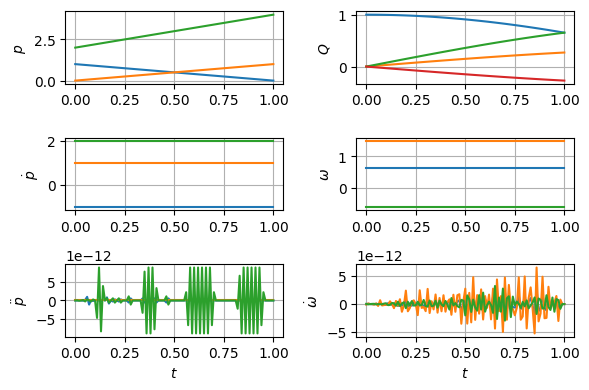

In [9]:
xt, vt, at = cline(t2x(T0), t2x(T1), t)
_ = plotctraj(t, xt, vt, at, fig_size=(6, 4))

The function `ctraj(x0, x1, t, fun)` lets you provide the scalar motion profile as an input argument. This is useful when the geometric interpolation should remain the same but the timing profile should be customized.


In [10]:
xt, vt, at = cpoly(t2x(T0), t2x(T1), t)
xt, vt, at = ctraj(t2x(T0), t2x(T1), t, traj="Poly")

The two calls above generate the same trajectory.

The function `carctraj` generates Cartesian motion along an arc. Its velocity profile can be selected in the same way as for `ctraj`.


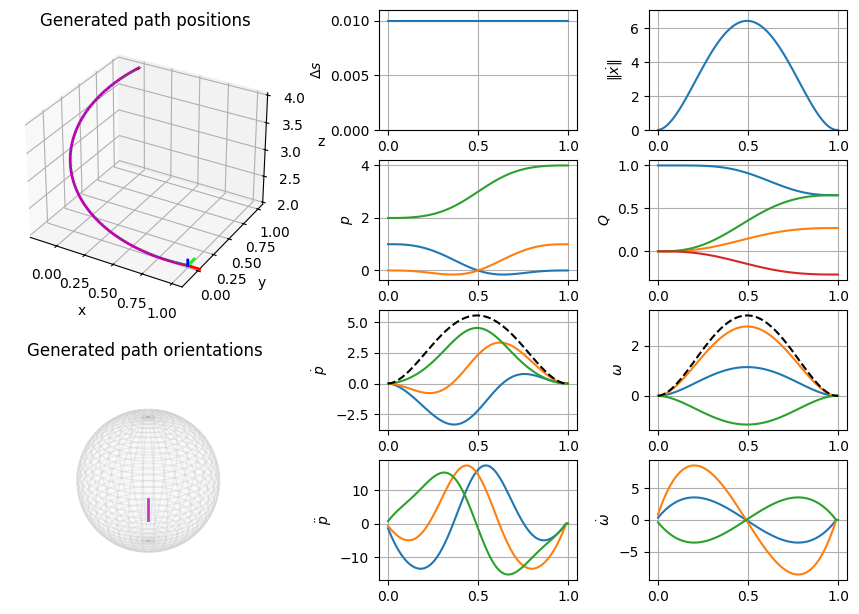

In [20]:
T0 = rp2t(np.eye(3), [1, 0, 2], out="T")
T1 = rp2t(rot_y(np.pi / 2, out="R") @ rot_x(np.pi / 4, out="R"), [0, 1, 4], out="T")
pC = [1, 1, 3]
t = np.arange(0, 1.0001, 0.01)
xt, vt, at = carctraj(t2x(T0), t2x(T1), pC, t)
hx, ax = plotcpath(t, xt)
ax[1].view_init(elev=30, azim=45)

# Path generation and interpolation

The trajectory-generation functions above create motion between two positions, with motion starting at the initial position and stopping at the final position. For more complex motion through or near multiple points, RobotBlockSet provides path utilities.

| Function | Description |
| --- | --- |
| `xnew = interpPath(s, x, snew)` | Interpolate a path for query path values. |
| `xnew = interpCartesianPath(s, x, snew)` | Interpolate a Cartesian path for query path values. |
| `xnew = interpQuaternionPath(s, Q, snew)` | Interpolate a quaternion path for query path values. |
| `x = uniqueCartesianPath(x)` | Flip quaternion signs in a Cartesian path so consecutive quaternion dot products stay positive. |
| `Q = uniqueQuaternionPath(Q)` | Flip quaternion signs in a quaternion path so consecutive quaternion dot products stay positive. |
| `[xi, si] = pathoverpoints(points, ...)` | Generate a path over or near points using spline, RBF, or auxiliary-point interpolation. |
| `auxpnt = pathauxpoints(points, ...)` | Generate auxiliary points for path construction. |
| `[send, si] = pathlen(path, scale)` | Calculate path length using positions, orientations, or both. |
| `[px, d] = distance2line(p0, p, dir)` | Find the closest point on a line and calculate distance. |
| `[px, d, sx] = distance2path(x, path, s, scale)` | Find the closest point on a path and calculate distance. |
| `qout = qspline(q, s, mode)` | Interpolate quaternions in spherical space. |
| `xd = gradientPath(x, t)` | Calculate a derivative along a path. |
| `xd = gradientCartesianPath(x, t)` | Calculate a derivative along a Cartesian path. |
| `Qd = gradientQuaternionPath(Q, t)` | Calculate a derivative along a quaternion path. |

## Path interpolation

Path interpolation is available for joint-space and task-space paths. For joint-space paths, use `interpPath`, which wraps standard linear interpolation.


In [12]:
qpath = np.array([[1, 0, 2, -1], [2, 1, 2, 3], [0, 3, -2, 2]], dtype=float)
s = np.arange(1, 4)
si = np.linspace(1, 3, 6)
qi = interpPath(s, qpath, si)
print(qi)

[[ 1.   0.   2.  -1. ]
 [ 1.4  0.4  2.   0.6]
 [ 1.8  0.8  2.   2.2]
 [ 1.6  1.4  1.2  2.8]
 [ 0.8  2.2 -0.4  2.4]
 [ 0.   3.  -2.   2. ]]


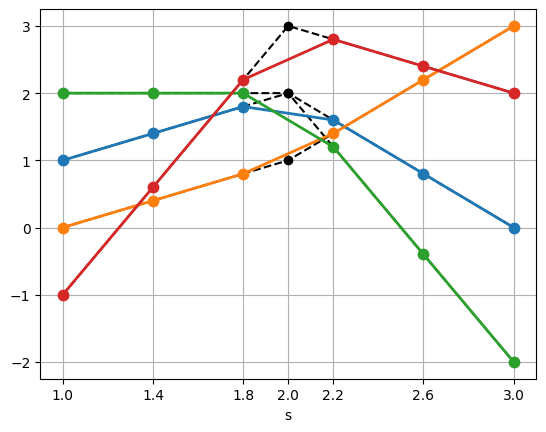

In [13]:
plt.figure(1)
plt.plot(s, qpath, "ko--")
plt.plot(si, qi, ".-", linewidth=2, markersize=15)
plt.grid(True)
plt.xticks(np.union1d(s, si))
_ = plt.xlabel("s")

Quaternion path interpolation uses SLERP through `interpQuaternionPath`.


In [14]:
q = np.array(
    [
        [1.0000, 0.0000, 0.0000, 0.0000],
        [0.7071, 0.0000, 0.7071, 0.0000],
        [0.0000, 1.0000, -0.0000, 0.0000],
        [1.0000, 0.0000, 0.0000, 0.0000],
    ]
)
s = np.arange(1, 5)
si = np.linspace(1, 4, 9)
qi = interpQuaternionPath(s, q, si)
print(qi)

[[1.     0.     0.     0.    ]
 [0.9569 0.     0.2903 0.    ]
 [0.8315 0.     0.5556 0.    ]
 [0.6935 0.1951 0.6935 0.    ]
 [0.5    0.7071 0.5    0.    ]
 [0.1379 0.9808 0.1379 0.    ]
 [0.3827 0.9239 0.     0.    ]
 [0.8315 0.5556 0.     0.    ]
 [1.     0.     0.     0.    ]]


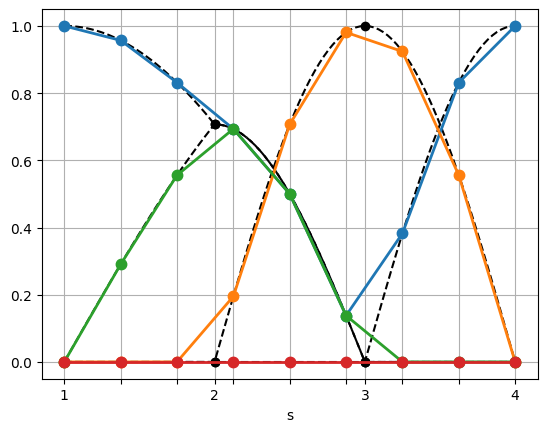

In [15]:
ssi = np.linspace(1, 4, 100)
qqi = interpQuaternionPath(s, q, ssi)

plt.figure(2)
plt.plot(s, q, "ko")
plt.plot(ssi, qqi, "k--")
plt.plot(si, qi, ".-", linewidth=2, markersize=15)
plt.grid(True)
plt.xticks(np.union1d(s, si), ["1", "", "", "2", "", "", "", "3", "", "", "4"])
_ = plt.xlabel("s")

Cartesian path interpolation combines linear interpolation for position with spherical interpolation for orientation.


In [16]:
x = np.array(
    [
        [1, 0, 0, 1.0000, 0.0000, 0.0000, 0.0000],
        [2, -1, 2, 0.7071, 0.0000, 0.7071, 0.0000],
        [4, 3, 2, 0.0000, 1.0000, -0.0000, 0.0000],
        [3, 3, 0, 1.0000, 0.0000, 0.0000, 0.0000],
    ]
)
s = np.arange(1, 5)
si = np.linspace(1, 4, 100)
xi = interpCartesianPath(s, x, si)

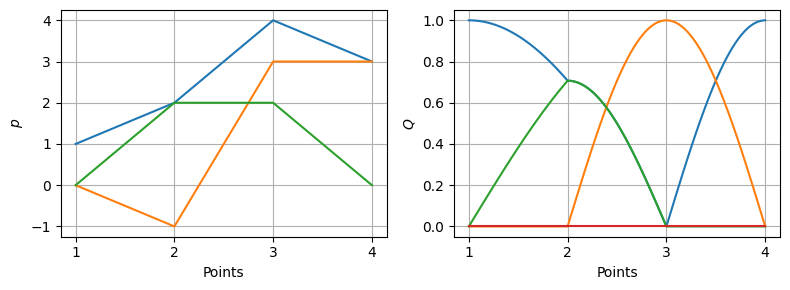

In [17]:
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(8, 3))
plotcpos_ori(si, xi, graph="time", typ="Pos", ax=axes[0])
axes[0].set_xticks([1, 2, 3, 4])
axes[0].set_xlabel("Points")
axes[0].grid(True)
plotcpos_ori(si, xi, graph="time", typ="Ori", ax=axes[1])
axes[1].set_xticks([1, 2, 3, 4])
axes[1].set_xlabel("Points")
axes[1].grid(True)
plt.tight_layout()

## Path gradients and derivatives

Use `gradientPath` for joint-space paths and pure position paths. If orientations are included, use `gradientQuaternionPath` or `gradientCartesianPath`.

Velocities can be calculated when the independent variable is time, meaning the path has become a trajectory. In that case, the independent variables, such as `s` and `t` in the example, must have the same initial and final values.


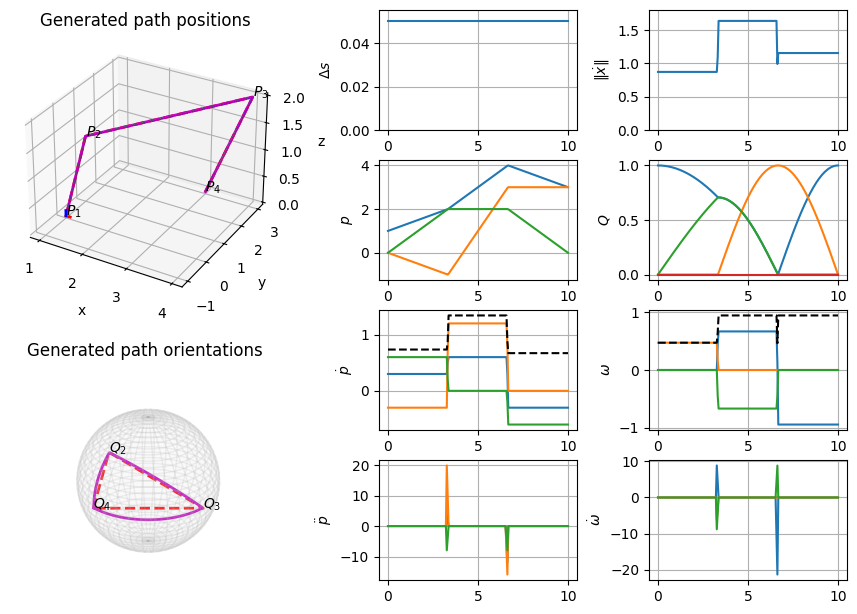

In [18]:
x = np.array(
    [
        [1, 0, 0, 1.0000, 0.0000, 0.0000, 0.0000],
        [2, -1, 2, 0.7071, 0.0000, 0.7071, 0.0000],
        [4, 3, 2, 0.0000, 1.0000, -0.0000, 0.0000],
        [3, 3, 0, 1.0000, 0.0000, 0.0000, 0.0000],
    ]
)
tmax = 10
s = np.linspace(0, tmax, 4)
t = np.linspace(0, tmax, 200)
xt = interpCartesianPath(s, x, t)
vt = gradientCartesianPath(xt, t)
at = gradientPath(vt, t)
hx, ax = plotcpath(t, xt, points=x, ori_sel=[1, 2])
ax[1].view_init(elev=30, azim=45)

![](README.assets/gradientCartesianPath_1.png)

> **Note:** For path acceleration, use `gradientPath`, because rotational velocities already form a vector space.

## Unique quaternion paths

The quaternions $Q$ and $-Q$ represent the same orientation. In a task-space path, a quaternion sequence can therefore switch between equivalent signs, which can introduce discontinuities in plots, interpolation, and derivative calculations.

RobotBlockSet provides `uniqueQuaternionPath(Q)` and `uniqueCartesianPath(x)` to make quaternion signs consistent along a path. They flip quaternion signs when needed so the dot product between consecutive quaternions remains positive.


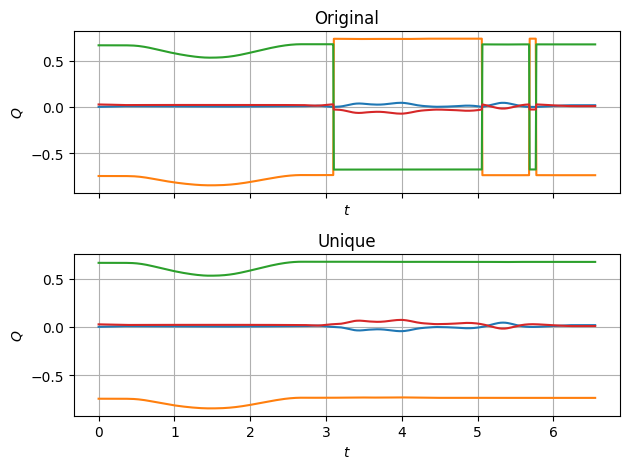

In [20]:
data = loadmat("assets/sample_traj.mat")
cart_traj = data["cart_traj"]
time = data["time"].squeeze()

fig, axes = plt.subplots(2, 1, sharex=True)
plotcpos_ori(time, cart_traj, graph="time", typ="Ori", ax=axes[0])
axes[0].set_title("Original")
cart_traj_u = uniqueCartesianPath(cart_traj)
plotcpos_ori(time, cart_traj_u, graph="time", typ="Ori", ax=axes[1])
axes[1].set_title("Unique")
plt.tight_layout()

## Paths via multiple points

Use `pathoverpoints` to generate smooth paths from an initial point, through or near intermediate points, to a final point. The function provides several options for controlling interpolation and auxiliary points.

| Option | Values | Description |
| --- | --- | --- |
| `interp` | **`"inner"`**, `"spline"`, `"RBF"`, `"none"` | Interpolation type: inner spline by uniform subdivision, cubic spline, RBF approximation, or no interpolation. |
| `step` | `0.01` | Maximum difference in path parameter between samples. |
| `n_points` | `0` | Minimum number of path points. If `0`, `step` is used instead. |
| `auxpoints` | `"absolute"`, `"relative"`, **`"none"`** | Auxiliary-point mode. `"absolute"` uses absolute auxiliary distances; `"relative"` uses relative segment distances; `"none"` disables auxiliary points. |
| `auxdistance` | `[0.1, 0.2]` | Auxiliary-point distance for position and orientation. |
| `order` | `4` | Order of the inner spline (`>= 3`). |
| `natural` | `True`, **`False`** | If `True`, use path distance as the path parameter. |
| `normscale` | `0` | Scaling factor for the rotation norm. |
| `plot` | `True`, **`False`** | Generate diagnostic plots. |
| `ori_sel` | `[1, 2]` | Orientation components used in selected plots. |

Defaults are shown in bold.

For example, generate a smooth path over the following points.


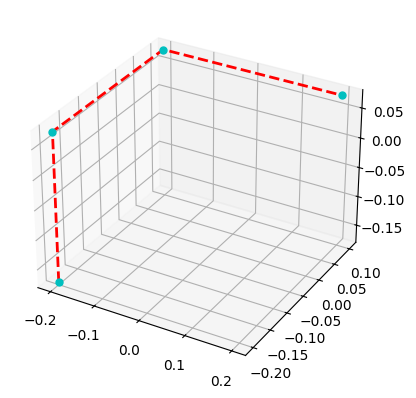

In [21]:
pte = np.array(
    [
        [-0.2, -0.2, -0.175, 0, 0, 0],
        [-0.2, -0.2, 0.075, 0, 0, -np.pi / 2],
        [-0.2, 0.1, 0.075, -np.pi / 2, 0, -np.pi / 2],
        [0.2, 0.1, 0.075, -np.pi, 0, -np.pi / 2],
    ]
)
pt = prpy2x(pte)
_ = plotpathpoints(
    pt,
)

Changing the options produces different paths. First, generate a path with the `"inner"` spline, `order=4`, and no auxiliary points.


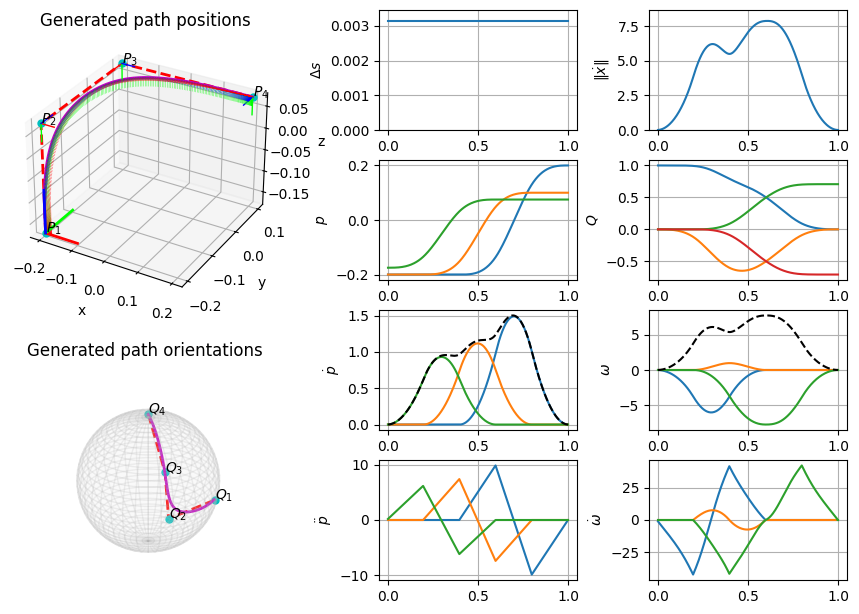

In [22]:
xi, si = pathoverpoints(pt, step=0.01, order=4, plot=True)

The generated path approaches the intermediate points but does not necessarily pass through them. The distance to the points depends on `order`.

The generated accelerations are not smooth in this case. Increasing the interpolation order makes the path smoother, but it can also increase the distance to intermediate points.


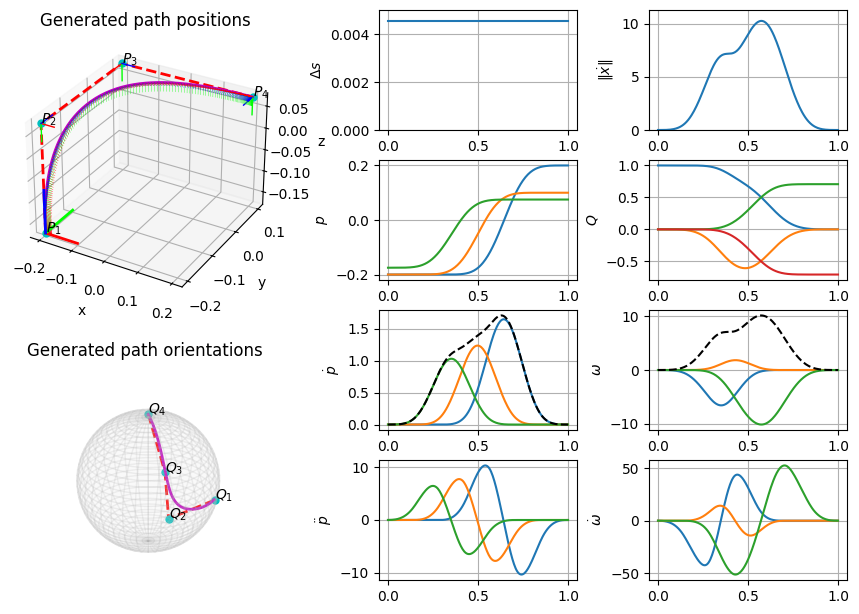

In [23]:
xi, si = pathoverpoints(pt, step=0.01, order=6, plot=True)

To make the path pass closer to the intermediate points, add auxiliary points. In this example, relative auxiliary points are added for both position and orientation.


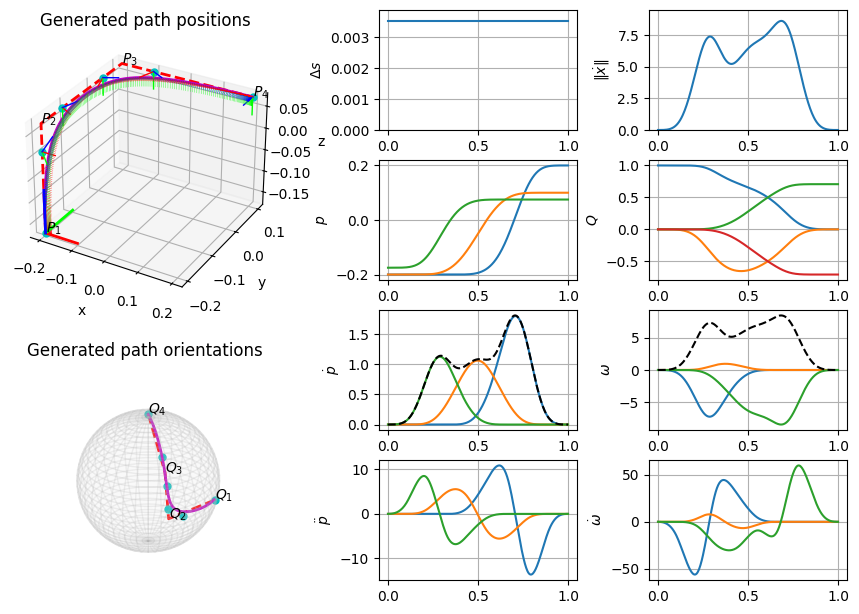

In [24]:
xi, si = pathoverpoints(pt, step=0.01, order=6, auxpoints="relative", auxdistance=0.25, plot=True)

Here, auxiliary points are added only for position. The orientation at each auxiliary point is copied from the opposite side of the segment where the auxiliary position point is inserted.


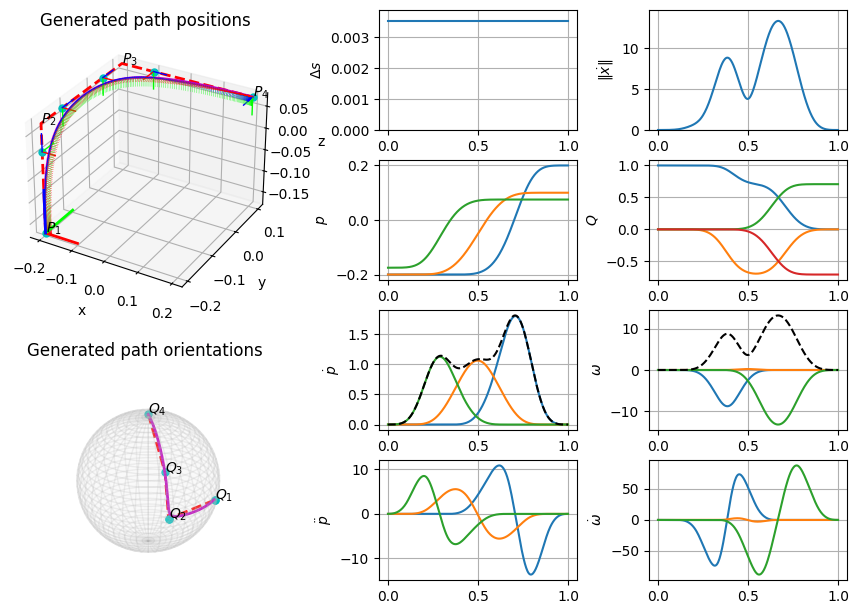

In [25]:
xi, si = pathoverpoints(pt, step=0.01, order=6, auxpoints="relative", auxdistance=[0.25, 0], plot=True)

With `viapoints=True`, `pathoverpoints` uses only the auxiliary points for path generation. The original intermediate, or via, points are then omitted from the generated path.


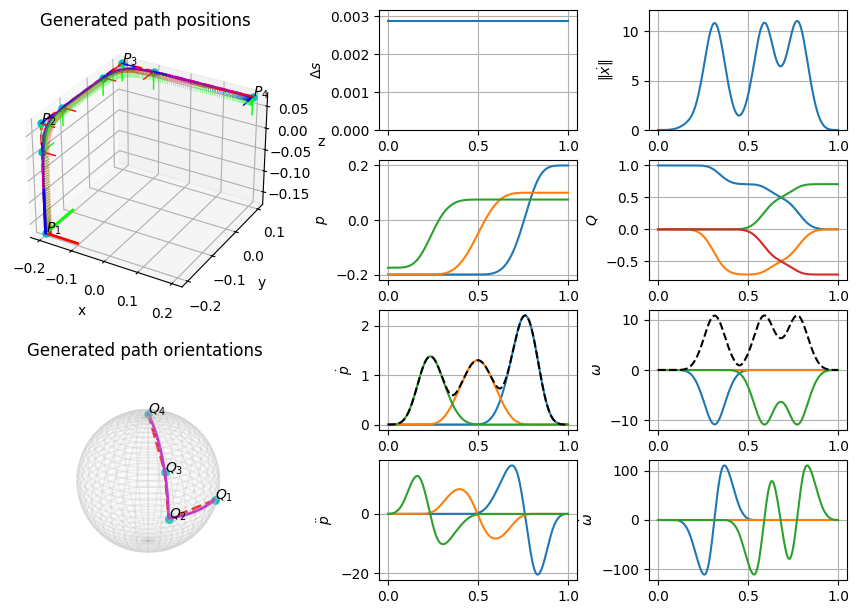

In [26]:
xi, si = pathoverpoints(pt, step=0.01, order=6, auxpoints="relative", auxdistance=[0.25, 0], viapoints=True, plot=True)

With `"spline"` interpolation, the generated path passes through the intermediate points.


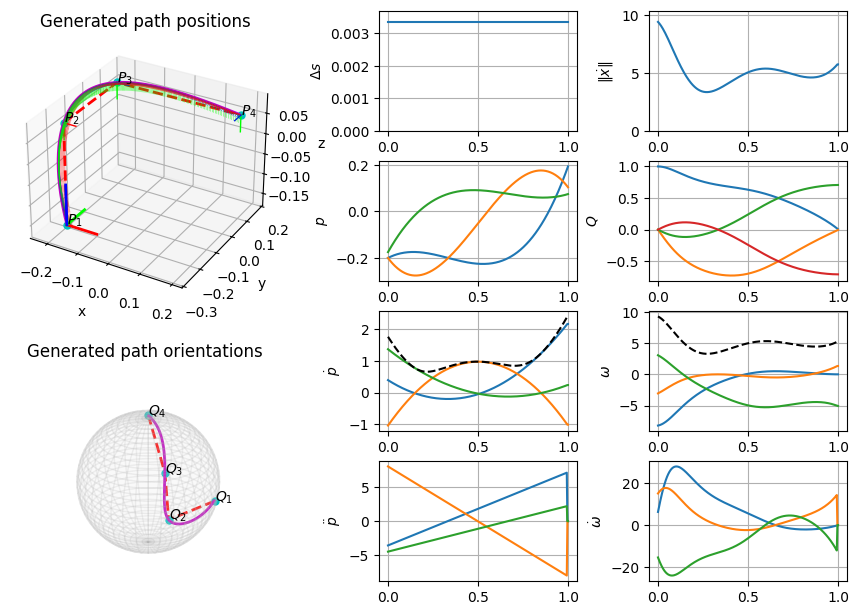

In [27]:
xi, si = pathoverpoints(pt, step=0.01, interp="spline", plot=True)

RBF path generation can also be used over multiple points. Compared with spline interpolation, it can additionally specify initial and final velocity and acceleration conditions.


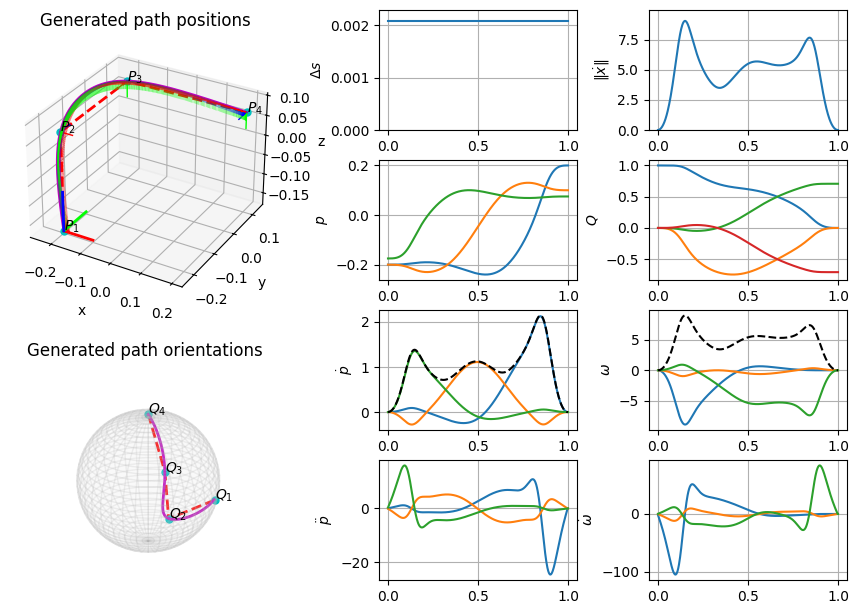

In [28]:
xi, si = pathoverpoints(pt, step=0.01, interp="RBF", plot=True)

So far, the path samples have been distributed uniformly over the normalized path parameter, with `s = 0` at the start and `s = 1` at the final point. As a result, changes between consecutive samples, or $\|\dot{x}\|$, are not necessarily constant.

With `natural=True`, the path parameter is defined by path length:

$$
s(k) = \sum_{i=2}^k \sqrt{\|p_k - p_{k-1}\|^2 + a^2 \|2\log(Q_k Q_{k-1}^{-1})\|^2}
$$

where $p_k$ are positions, $Q_k$ are orientations, and `normscale` sets the rotation scaling factor $a$. Using the natural path parameter makes the weighted path norm approximately constant.

For this example, a useful choice is `normscale=[1, 0.1]`.


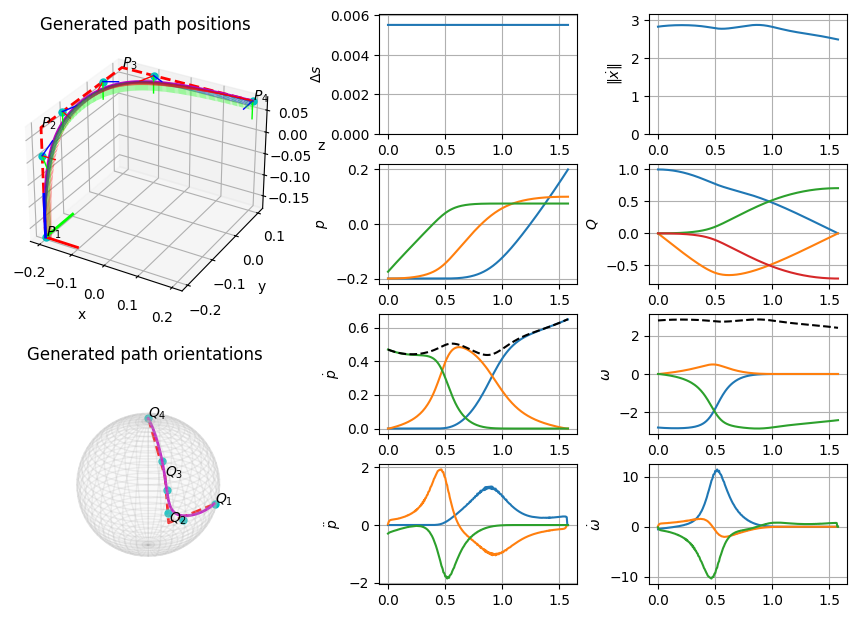

In [29]:
xi, si = pathoverpoints(pt, step=0.01, natural=True, normscale=[1, 0.1], order=6, auxpoints="relative", auxdistance=0.25, plot=True)

## Orientation interpolation

In `pathoverpoints`, orientation interpolation is not based directly on SLERP. If a specific orientation interpolation method is required, use `qspline`, which supports two modes:

| Parameter | Values | Description |
| --- | --- | --- |
| `mode` | `"hermite_cubic"`, `"squad"` | `"hermite_cubic"` uses a cubic curve with a Bezier-Bernstein basis. `"squad"` uses spherical quaternion angle interpolation, analogous to bilinear interpolation in Euclidean space. |

The following example compares several quaternion interpolation methods.


In [30]:
q = np.array(
    [
        [1.0000, 0.0000, 0.0000, 0.0000],
        [0.7071, 0.0000, 0.7071, 0.0000],
        [0.0000, 1.0000, -0.0000, 0.0000],
        [1.0000, 0.0000, 0.0000, 0.0000],
    ]
)
s = np.arange(0, 4)
si = np.linspace(0, 3, 9)
qi = interpQuaternionPath(s, q, si)
print(qi)

[[1.     0.     0.     0.    ]
 [0.9569 0.     0.2903 0.    ]
 [0.8315 0.     0.5556 0.    ]
 [0.6935 0.1951 0.6935 0.    ]
 [0.5    0.7071 0.5    0.    ]
 [0.1379 0.9808 0.1379 0.    ]
 [0.3827 0.9239 0.     0.    ]
 [0.8315 0.5556 0.     0.    ]
 [1.     0.     0.     0.    ]]


In [21]:
xi, si = pathoverpoints(np.hstack((np.zeros((4, 3)), q)), interp="spline")
q_slerp = uniqueQuaternionPath(interpQuaternionPath(s / s[-1],q,si))
q_spline = uniqueQuaternionPath(xi[:, 3:])
q_squad = uniqueQuaternionPath(qspline(q, si, "squad"))
q_hermite = uniqueQuaternionPath(qspline(q, si, "hermite_cubic"))

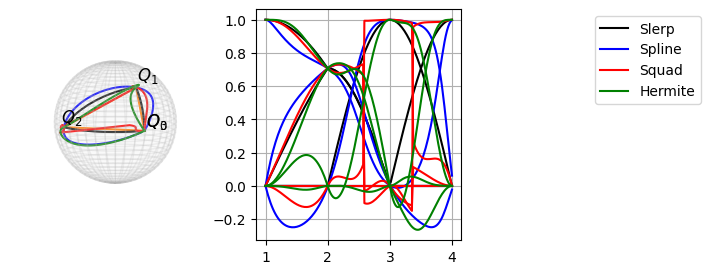

In [ ]:
# Assumes q, s, t, q_slerp, q_spline, q_squad, q_hermite, ti are defined
t = si.copy()
n = q.shape[0]
tt = t * (n - 1) + 1

fig = plt.figure(4)
fig.clf()
fig.set_size_inches(9, 3)
gs = fig.add_gridspec(1, 3)
ax3d = fig.add_subplot(gs[0], projection="3d")
ax_q = fig.add_subplot(gs[1])
ax_l = fig.add_subplot(gs[2])
ax_l.axis("off")

h0, _ = plotcpos_ori(s, Q=q, graph="3D", typ="Ori", ax=ax3d, label=True)
h1 = ax3d.plot(q_slerp[:, 0], q_slerp[:, 1], q_slerp[:, 2], 'k')
h2 = ax3d.plot(q_spline[:, 0], q_spline[:, 1], q_spline[:, 2], 'b')
h3 = ax3d.plot(q_squad[:, 0], q_squad[:, 1], q_squad[:, 2], 'r')
h4 = ax3d.plot(q_hermite[:, 0], q_hermite[:, 1], q_hermite[:, 2], 'g')
ax3d.view_init(-10, -150)
plt.legend([h1[0], h2[0], h3[0], h4[0]], ["Slerp", "Spline", "Squad", "Hermite"], loc="best" )

ax_q.plot(tt, q_slerp, 'k')
ax_q.plot(tt, q_spline, 'b')
ax_q.plot(tt, q_squad, 'r')
ax_q.plot(tt, q_hermite, 'g')
ax_q.grid("on")


![](README.assets/qspline_1.png)

## Path utilities

Path utility functions provide information such as path length or distance to a path. Path length is calculated as a weighted sum of distances between path points:

$$
s(k) = \sum_{i=2}^k \sqrt{s_p\|p_k - p_{k-1}\|^2 + s_Q\|2\log(Q_k Q_{k-1}^{-1})\|^2}
$$

where $p_k$ are positions, $Q_k$ are orientations, and $s_p$ and $s_Q$ are the weights for position and orientation distances.


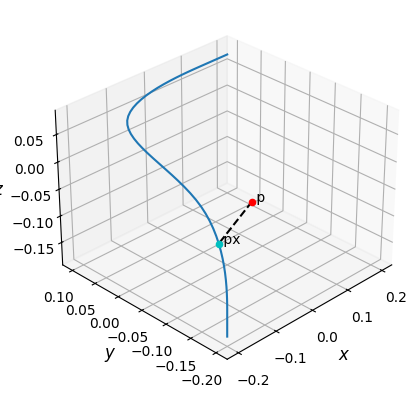

In [31]:
pte = np.array(
    [
        [-0.2, -0.2, -0.175, 0, 0, 0],
        [-0.2, -0.2, 0.075, 0, 0, -np.pi / 2],
        [-0.2, 0.1, 0.075, -np.pi / 2, 0, -np.pi / 2],
        [0.2, 0.1, 0.075, -np.pi, 0, -np.pi / 2],
    ]
)
pt = prpy2x(pte)
path, si = pathoverpoints(pt, n_points=51)
s = np.linspace(0, 1, path.shape[0])
length = pathlen(path, [1, 0])
p = np.array([0, -0.1, -0.05])
px, d, sx = distance2path(p, path[:, :3], s)
hx, ax = plotcpos_ori(s, path, typ="Pos", graph="3D")
ax.view_init(elev=30, azim=-135)
ax.scatter(p[0], p[1], p[2], color="r")
ax.text(p[0], p[1], p[2], " p")
ax.scatter(px[0], px[1], px[2], color="c")
ax.text(px[0], px[1], px[2], " px")
_ = ax.plot([p[0], px[0]], [p[1], px[1]], [p[2], px[2]], "k--")

When orientations are included, distance is defined as:

$$
d = \sqrt{s_p\|p_e\|^2 + s_Q\|Q_e\|^2}
$$

where $p_e$ and $Q_e$ are the position and orientation errors between the point `p` and the closest point `px` on the path. The weights define the relative importance of position and orientation errors.


In [32]:
p

array([ 0.  , -0.1 , -0.05])

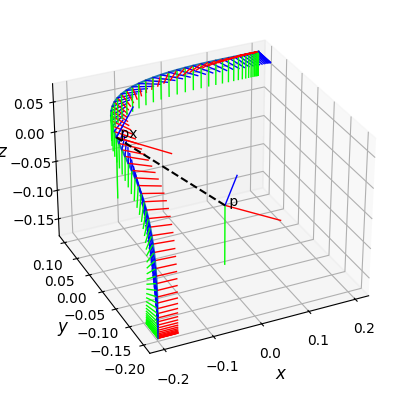

In [33]:
p = map_pose(p=[0, -0.1, -0.05], RPY=[-np.pi / 4, 0, -np.pi / 2])
px, d, sx = distance2path(p, path, s, [1, 0.1])
_, ax = plotcpos_ori(s, path, typ="Pos", graph="3D", UCS=True)
ax.view_init(elev=30, azim=-115)
_, ax =plotucs(p, UCS_length=0.1)
ax.text(p[0], p[1], p[2], " p")
_, ax =plotucs(px, UCS_length=0.1)
ax.text(px[0], px[1], px[2], " px")
_ = plt.plot([p[0], px[0]], [p[1], px[1]], [p[2], px[2]], "k--")

# Path approximations

## Radial basis functions (RBF)

If a path or trajectory is captured from robot motion, for example by kinesthetic guidance, it can be approximated with radial basis functions (RBF). RobotBlockSet uses Gaussian kernels of the form:

$$
\Psi(x) = e^{-\frac{(x - c)^2}{2\sigma}}
$$

where $c$ is the kernel center and $\sigma$ controls the kernel width. Gaussian kernels are smooth and provide $\mathcal{C}^{\infty}$ continuity.

The approximation function $f$ for captured data $\mathbf{y}$ is written as a normalized weighted sum of radial basis functions:

$$
f(x) = \frac{\sum_{j=1}^m w_j \Psi_j(x)}{\sum_{j=1}^m \Psi_j(x)}
$$

where $m$ is the number of kernels. Define the normalized basis vector $\mathbf{\Phi}$ as:

$$
\mathbf{\Phi}_k(x) = \frac{\Psi_k(x)}{\sum_{j=1}^m \Psi_j(x)}
$$

Then:

$$
f(x) = \mathbf{\Phi}(x)\mathbf{w}
$$

For a set of sampled data points, this gives a linear system:

$$
\mathbf{A}\mathbf{w} = \mathbf{y}
$$

where $\mathbf{y}$ contains the sampled data and $\mathbf{A}$ contains rows $\mathbf{\Phi}(x_i)$. The corresponding weights are:

$$
\mathbf{w} = \mathbf{A}^{-1}\mathbf{y}
$$

RobotBlockSet provides the following RBF utilities:

| Function | Description |
| --- | --- |
| `RBF = encodeRBF(x, y, N, c, sigma2, bc, coff, sfac)` | Calculate Gaussian RBF weights, optionally including initial and final velocity/acceleration constraints. |
| `y, ydot, yddot, ydddot = decodeRBF(x, RBF)` | Decode scalar or vector path values and derivatives from an RBF representation. |
| `x, v, a = decodeCartesianRBF(x, RBF)` | Decode a Cartesian path and derivatives from an RBF representation. |
| `q, w, wdot = decodeQuaternionRBF(x, RBF)` | Decode a quaternion path and angular derivatives from an RBF representation. |
| `J, Jdot = jacobiRBF(x, RBF)` | Calculate the RBF Jacobian and its derivative using numerical differentiation. |
| `y, RBF = updateRBF(x, y, RBF)` | Update RBF weights with recursive regression. |

Quaternion data is encoded component-wise, but quaternion decoding normalizes the result so returned quaternions have unit norm.

The following example approximates a captured Cartesian end-effector path with `encodeRBF` and reconstructs it with `decodeCartesianRBF`.


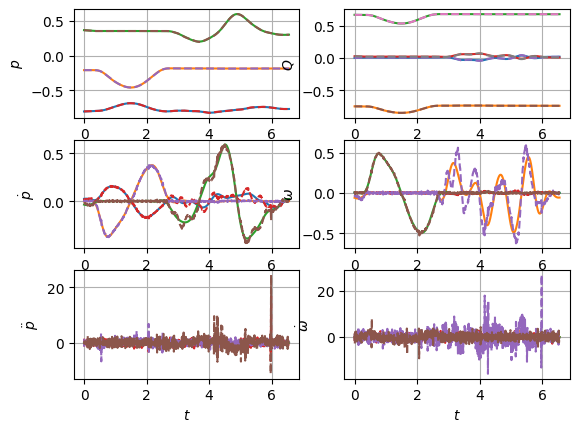

In [34]:
data = loadmat("assets/sample_traj.mat")
cart_traj = data["cart_traj"]
time = data["time"].squeeze()
x = uniqueCartesianPath(cart_traj)
RBF = encodeRBF(time, x, N=25)
x_rbf = decodeCartesianRBF(time, RBF)
_, ax = plotctraj(time, x_rbf)
_ = plotctraj(time, x, ax=ax, linestyle='dashed')
